# Financial Performance Analysis 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind


In [3]:

df = pd.read_csv("Sales Records.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      100 non-null    int64         
 1   Region          100 non-null    object        
 2   Country         100 non-null    object        
 3   Item Type       100 non-null    object        
 4   Sales Channel   100 non-null    object        
 5   Order Priority  100 non-null    object        
 6   Order Date      100 non-null    datetime64[ns]
 7   Order ID        100 non-null    int64         
 8   Ship Date       100 non-null    datetime64[ns]
 9   Units Sold      100 non-null    int64         
 10  Unit Price      100 non-null    float64       
 11  Unit Cost       100 non-null    float64       
 12  Total Revenue   100 non-null    float64       
 13  Total Cost      100 non-null    float64       
 14  Total Profit    100 non-null    float64       
 15  month_n

(100, 17)

## Revenue Analysis

**Objective:** To evaluate how sales are distributed across regions, countries, product categories, and months in order to identify top-performing segments and trends.

In [4]:
region_sales = df.groupby("Region")["Total Revenue"].sum().sort_values(ascending=False).reset_index()
print(region_sales)


                              Region  Total Revenue
0                 Sub-Saharan Africa    39672031.43
1                             Europe    33368932.11
2                               Asia    21347091.02
3              Australia and Oceania    14094265.13
4       Middle East and North Africa    14052706.58
5  Central America and the Caribbean     9170385.49
6                      North America     5643356.55


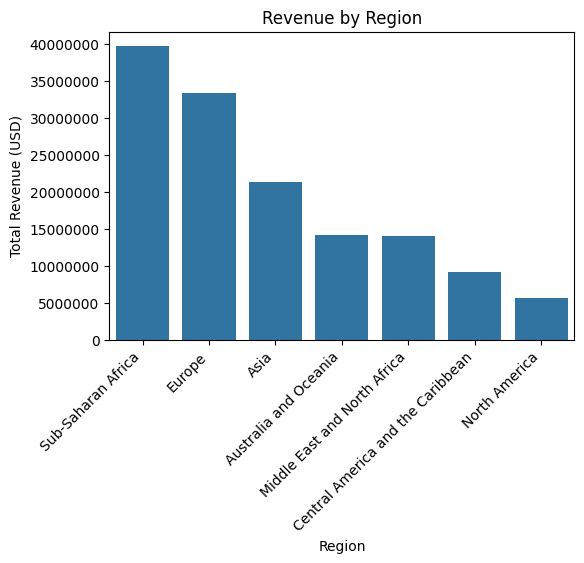

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(data=region_sales, x="Region", y="Total Revenue")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 45 , ha="right")
plt.show()

### Regional Revenue Insights
Revenue analysis by region shows that Sub-Saharan Africa is the highest revenue-generating region, followed by Europe, indicating strong market performance in these areas. Asia and Australia & Oceania contribute a moderate share of revenue, suggesting stable but comparatively lower performance. In contrast, North America and Central America & the Caribbean generate the least revenue, highlighting potential opportunities for market expansion and improved sales strategies in these regions.

In [6]:

country_sales = df.groupby("Country")["Total Revenue"].sum().sort_values(ascending=False).reset_index().head(10)
print(country_sales)




        Country  Total Revenue
0      Honduras     6336545.48
1       Myanmar     6161257.90
2      Djibouti     6052890.86
3  Turkmenistan     5822036.20
4        Mexico     5643356.55
5    The Gambia     5449517.95
6     Lithuania     5396577.27
7        Rwanda     5253769.42
8    Azerbaijan     4478800.21
9        Brunei     4368316.68


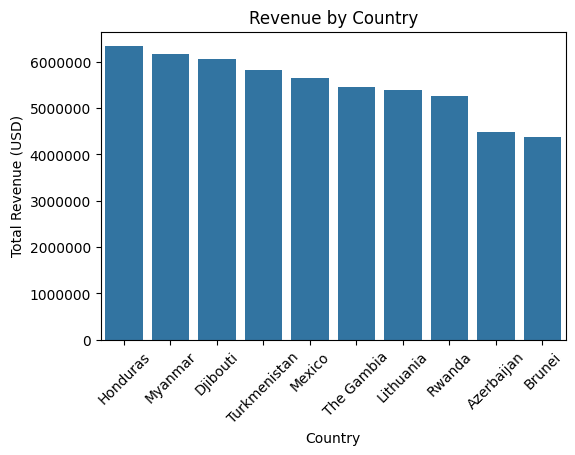

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(data=country_sales, x="Country", y="Total Revenue")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Total Revenue (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Revenue by Country")
plt.show()

### Country-wise Revenue Insights 
The analysis of the top 10 revenue-generating countries shows that Honduras, Myanmar, and Djibouti contribute the highest share of revenue, indicating strong market demand and effective sales performance in these markets. Countries such as Turkmenistan, Mexico, and The Gambia demonstrate moderate revenue levels, suggesting stable but improvable performance. In contrast, Rwanda, Azerbaijan, and Brunei contribute relatively lower revenue among the top 10, highlighting an opportunity for targeted marketing, pricing optimization, and distribution expansion. The company should focus on sustaining growth in high-performing countries while implementing localized strategies to improve revenue contribution in lower-performing markets within the top 10.

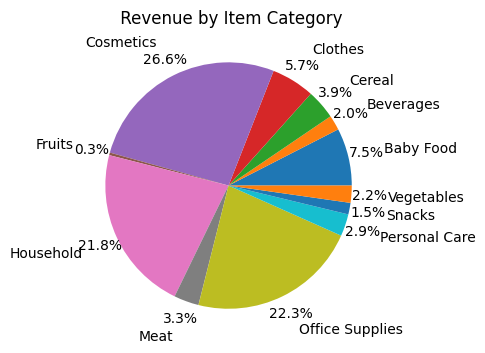

In [8]:
category_sales = df.groupby("Item Type")["Total Revenue"].sum()

plt.figure(figsize=(6,4))
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%",labeldistance=1.3,pctdistance=1.15)
plt.title(" Revenue by Item Category")
plt.show()


## Item Category Revenue Insights 
The revenue distribution by item category shows that Cosmetics, Office Supplies, and Household products contribute the largest share of total revenue, indicating strong and consistent customer demand in these categories. Categories such as Baby Food and Vegetables generate moderate revenue, suggesting stable but improvable performance. In contrast, Fruits, Meat, Snacks, and Personal Care contribute a relatively smaller share, highlighting opportunities for targeted promotions, pricing strategies, or product bundling to enhance sales. The company should continue investing in high-performing categories while adopting focused marketing and optimization strategies to improve revenue contribution from lower-performing categories.

## Profit Analysis
**Objective:** To evaluate profitability across product categories by identifying high-profit and low-profit segments and understanding opportunities for cost optimization and margin improvement.

In [9]:
region_profit = df.groupby("Region")["Total Profit"].sum().sort_values(ascending=False).reset_index()
print(region_profit)



                              Region  Total Profit
0                 Sub-Saharan Africa   12183211.40
1                             Europe   11082938.63
2                               Asia    6113845.87
3       Middle East and North Africa    5761191.86
4              Australia and Oceania    4722160.03
5  Central America and the Caribbean    2846907.85
6                      North America    1457942.76


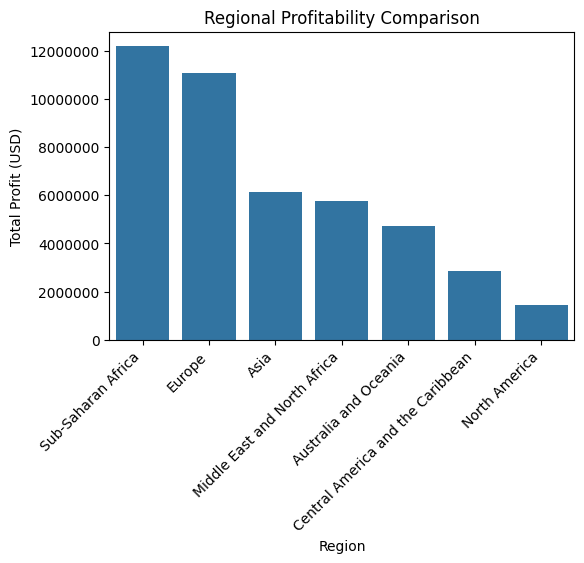

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(data=region_profit, x="Region", y="Total Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 45 , ha="right")
plt.title("Regional Profitability Comparison")
plt.show()

### Profit Analysis – Insight
The profit by region analysis shows that Sub-Saharan Africa and Europe contribute the highest total profit, indicating strong market performance and effective cost management in these regions. Asia and Middle East & North Africa generate moderate profit, suggesting stable but improvable profitability. In contrast, North America and Central America & the Caribbean contribute the lowest profit, highlighting potential issues related to higher costs, lower margins, or competitive pricing pressures. The company should focus on sustaining growth in high-profit regions while reviewing cost structures and pricing strategies in low-performing regions to improve overall profitability.

In [11]:
product_profit = (df.groupby("Item Type")["Total Profit"].sum().sort_values(ascending=False).reset_index())
print(product_profit)



          Item Type  Total Profit
0         Cosmetics   14556048.66
1         Household    7412605.71
2   Office Supplies    5929583.75
3           Clothes    5233334.40
4         Baby Food    3886643.70
5            Cereal    2292443.43
6        Vegetables    1265819.63
7     Personal Care    1220622.48
8         Beverages     888047.28
9            Snacks     751944.18
10             Meat     610610.00
11           Fruits     120495.18


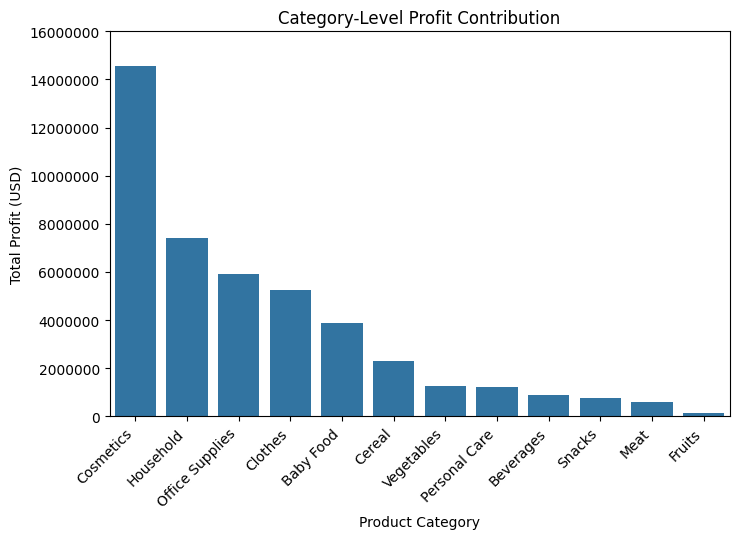

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=product_profit,x="Item Type",y="Total Profit")
plt.xlabel("Product Category")
plt.ylabel("Total Profit (USD)")
plt.title("Category-Level Profit Contribution")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,16000000)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Profit Analysis – Insight
The profit by product category analysis indicates that Cosmetics generate the highest total profit, followed by Household and Office Supplies, highlighting these categories as the most profitable and strategically important for the company. Clothes and Baby Food contribute moderate profit, reflecting stable performance with potential for growth. In contrast, categories such as Fruits, Meat, Snacks, and Beverages generate comparatively low profit, suggesting thinner margins, higher costs, or pricing pressure. To improve overall profitability, the company should continue investing in high-performing categories while reassessing pricing, sourcing, and cost-efficiency strategies for low-profit categories.

In [13]:
df["month_num"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.month_name()
cost_revenue_profit = df.groupby(["Month","month_num"])[["Total Revenue", "Total Cost", "Total Profit"]].sum().reset_index().sort_values("month_num")
print(cost_revenue_profit)

        Month  month_num  Total Revenue   Total Cost  Total Profit
4     January          1    10482467.12   7665610.10    2816857.02
3    February          2    24740517.77  17668467.26    7072050.51
7       March          3     2274823.87   1346472.81     928351.06
0       April          4    16187186.33  11426977.98    4760208.35
8         May          5    13215739.99   8633047.69    4582692.30
6        June          6     5230325.77   3044946.34    2185379.43
5        July          7    15669518.50  10091055.44    5578463.06
1      August          8     1128164.91    548888.24     579276.67
11  September          9     5314762.56   2970596.53    2344166.03
10    October         10    15287576.61  10780653.36    4506923.25
9    November         11    20568222.76  14110622.11    6457600.65
2    December         12     7249462.12   4893232.05    2356230.07


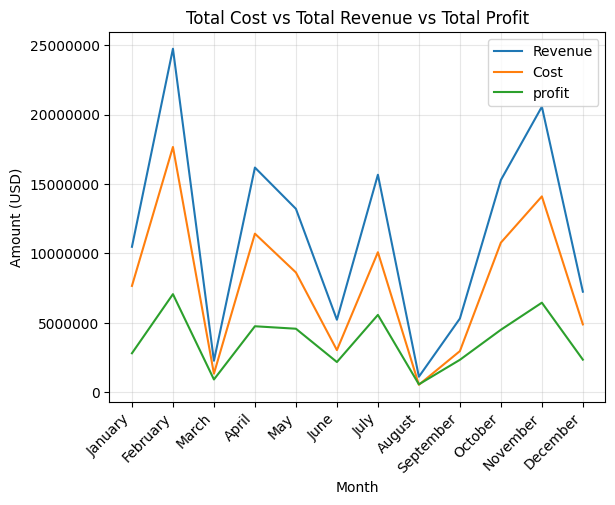

In [23]:
plt.plot(cost_revenue_profit["Month"], cost_revenue_profit["Total Revenue"], label="Revenue")
plt.plot(cost_revenue_profit["Month"], cost_revenue_profit["Total Cost"], label="Cost")
plt.plot(cost_revenue_profit["Month"], cost_revenue_profit["Total Profit"], label="profit")
plt.xlabel("Month")
plt.ylabel("Amount (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.3)
plt.xticks(rotation=45 , ha="right")
plt.legend()
plt.title("Total Cost vs Total Revenue vs Total Profit")
plt.show()


### Insight
The chart shows that costs closely follow revenue trends, but the gap between revenue and cost varies across months, directly impacting profit levels. In high-revenue months such as February and November, although costs also increase, revenue grows at a faster rate, resulting in higher profits. In contrast, during March and August, costs remain relatively high compared to revenue, leading to compressed profit margins. This pattern indicates that cost control is inconsistent, and periods of lower profitability are driven more by inefficient cost management rather than revenue decline alone. Improving cost efficiency during low-revenue months could help stabilize profits and reduce volatility.

## Hypothesis Testing
**Objective:** To statistically assess the financial impact of Online and Offline sales channels on revenue, profit, and cost.

**Null Hypothesis (H₀):**
There is no significant difference in average revenue between Online and Offline sales channels.

**Alternative Hypothesis (H₁):**
There is a significant difference in average revenue between Online and Offline sales channels.


In [15]:
online_rev = df[df["Sales Channel"] == "Online"]["Total Revenue"]
offline_rev = df[df["Sales Channel"] == "Offline"]["Total Revenue"]

t_stat, p_value = ttest_ind(online_rev, offline_rev, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference between Online and Offline sales")
else:
    print("Fail to reject H0: No significant difference between Online and Offline sales")




T-statistic: -1.4350442082570911
P-value: 0.15462738584535102
Fail to reject H0: No significant difference between Online and Offline sales


### Statistical Findings Summary
Hypothesis testing was conducted to evaluate the impact of sales channels on revenue, profit, and estimated cost. The results indicated no statistically significant difference in average revenue between Online and Offline channels. Similar tests were conducted for profit and estimated cost to assess overall financial impact.

In [16]:
from sklearn.linear_model import LinearRegression

X = df[["Total Revenue"]]
y = df["Total Profit"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", round(model.coef_[0], 2))
print("Intercept:", round(model.intercept_, 2))


Slope: 0.27
Intercept: 71494.96


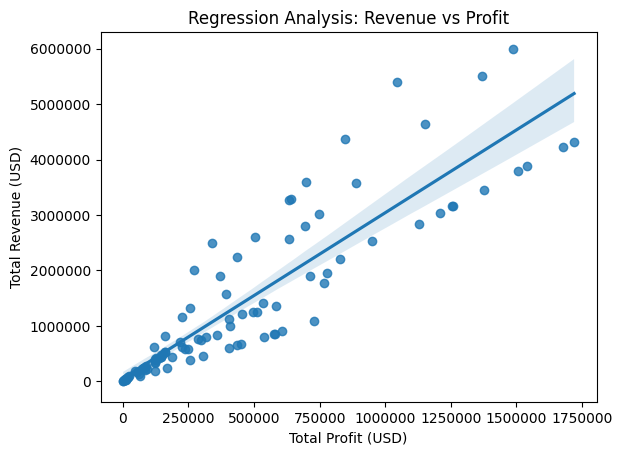

In [25]:
sns.regplot(x="Total Profit", y="Total Revenue", data=df)
plt.title("Regression Analysis: Revenue vs Profit")
plt.xlabel("Total Profit (USD)")
plt.ylabel("Total Revenue (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.show()


### Insight
This analysis shows that when revenue increases, profit also increases. This means the business is generally performing well and managing costs properly. However, at higher revenue levels, profit does not grow evenly, which shows that costs, discounts, or other expenses increase as sales grow. Some areas perform slightly worse than expected, which may indicate cost or pricing issues. Overall, the business shows stable performance with no major financial problems.

## Conclusion 
The analysis shows that revenue growth plays an important role in increasing profit, which means the business is generally converting sales into earnings effectively. As revenue rises, profit also improves, showing a healthy financial structure. However, profit does not grow evenly at higher revenue levels because operational costs, discounts, and other expenses increase. This creates some variation in profit performance across different business areas. While the overall financial position is stable, better control over costs and pricing is needed to maintain strong profit margins. Focusing on efficiency and cost management will help the company achieve sustainable growth and long-term profitability.

In [18]:
df.to_csv("Sales Records.CSV")